# 1 Install Libraries

In [1]:
pip install pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


# 2 Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 3 Load Dataset

In [3]:
df = pd.read_csv("Mall_Customers.csv")

print(df.head())
print(df.info())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None


# 4 Select Features

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 5 Data Visualization

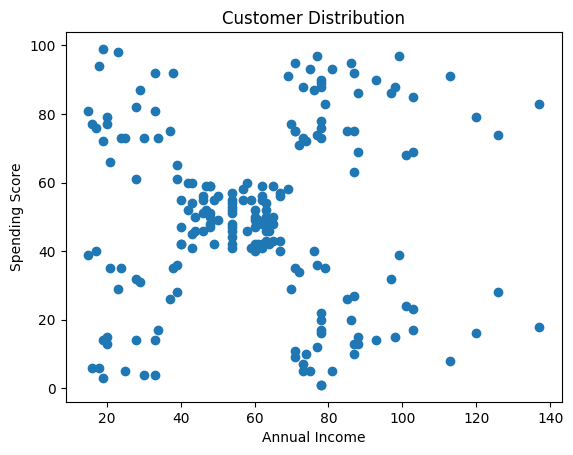

In [5]:
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'])

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")

plt.show()

# 6 Feature Scaling

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 7 Find Optimal Number of Clusters (Elbow Method)

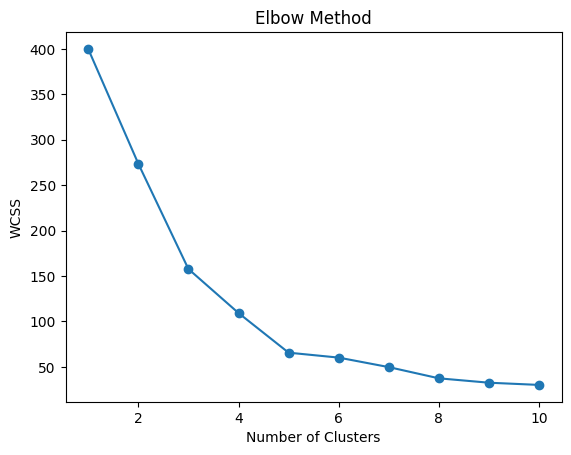

In [7]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

# 8 Apply K-Means Clustering

In [8]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

# 9 Visualize Clusters

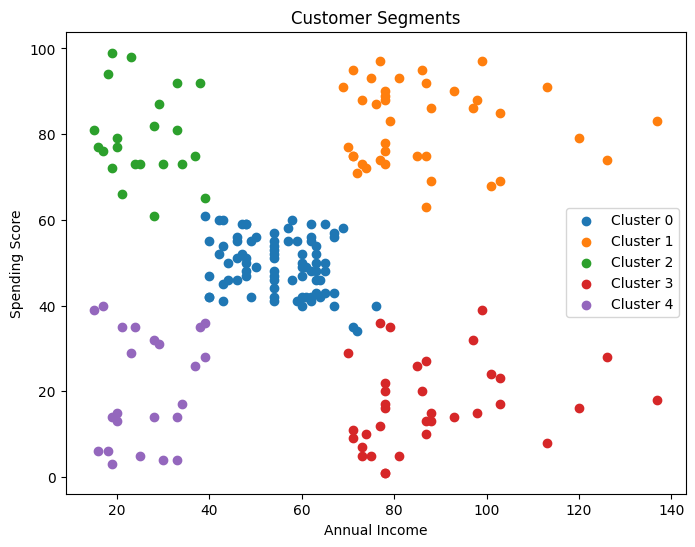

In [9]:
plt.figure(figsize=(8,6))

for i in range(5):
    plt.scatter(
        df[df['Cluster']==i]['Annual Income (k$)'],
        df[df['Cluster']==i]['Spending Score (1-100)'],
        label=f'Cluster {i}'
    )

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")

plt.legend()

plt.show()

# 10 Cluster Centers

In [10]:
print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Centers:
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


# 11 Evaluation (Silhouette Score)

In [11]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


#  Average Spending per Cluster

In [12]:
cluster_analysis = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

print(cluster_analysis)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


# DBSCAN Clustering

In [13]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

db_clusters = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_clusters

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  DBSCAN_Cluster  
0        4               0  
1        2               0  
2        4               0  
3        2               0  
4        4               0  
